In [2]:
#install dependencies, you can uncomment if needed
# %pip install scikit-image
# %pip install matplotlib
# %pip install numpy

# print("\nFinished installing scikit, matplotlib, and numpy\n")

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from skimage.transform import resize
import random
import os
from PIL import Image
import pandas as pd

## Preprocessing: Median filter and Gaussian Filter

In [3]:
import math
import numpy as np

#function for convolution, based on the matlab code showed in class
#This is using zero padding, so the result image is slightly larger than the original image.

def twoD_convolution(image, kernel):
    image_height = image.shape[0]
    image_width = image.shape[1]

    kernel_height = kernel.shape[0]
    kernel_width = kernel.shape[1]
    result_height = image_height + kernel_height - 1
    result_width = image_width + kernel_width - 1
    
    # Initialize result with zeros
    result = np.zeros((result_height, result_width))
    for i in range(image_height):
        for j in range(image_width):
            # For each pixel in the image, multiply it by the entire kernel
            # and add it to the corresponding neighborhood in the result
            result[i : i + kernel_height, j : j + kernel_width] += image[i, j] * kernel

    pad_h = kernel_height // 2
    pad_w = kernel_width // 2
    return result[pad_h : pad_h + image_height, pad_w : pad_w + image_width]

def median_filter(img, kernel_size):
    pad = kernel_size // 2
    #pad the image with zeros on the edges.
    padded = np.pad(img, pad, mode='constant', constant_values=0)

    #initialize the result matrix with zeros (same size as original image)
    result = np.zeros_like(img)
    
    #replace each pixel with the median of the neighboring pixels (inside the kernel)
    #this loops through the entire image
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = padded[i:i+kernel_size, j:j+kernel_size]
            result[i, j] = np.median(region)
    
    return result

def gaussian_filter_equation(x,y,sigma):
    return math.exp(-(x**2 + y**2) / (2 * sigma**2))

def gaussian_filter(img, kernel_size, sigma):
    k = kernel_size // 2
    kernel = np.zeros((kernel_size, kernel_size))
    for i in range(kernel_size):
        for j in range(kernel_size):
            kernel[i, j] = gaussian_filter_equation(i - k, j - k, sigma)
    kernel /= kernel.sum()
    return twoD_convolution(img, kernel)


### Reading in the images, converting them to grayscale using the Luminosity method, and using the filters.

In [4]:
from matplotlib.image import imread
from PIL import Image
def luminosity(image):
    r = 0.21
    g = 0.72
    b = 0.07
    img = image.copy()
    #create 3 copies of the original image.
    red = img[:, :, 0]
    green = img[:, :, 1]
    blue = img[:, :, 2]

    return (red* r) + (green * g) + (blue * b)

if not os.path.exists("median_filtered_images"):
    os.makedirs("median_filtered_images")
    print(f"Created folder: median_filtered_images")
else:
    print(f"Folder median_filtered_images already exists.")

# There are 10 dataset images, all named the same way (img_1, img_2, img_3...)
print("Median Filtering 10 Images\n")
for i in range(1, 11):
    print("Filtering Image " + str(i))
    #luminsoity -> median filter -> save the result to median_filtered_images folder
    current_image = luminosity(imread("dataset_images/img_" + str(i) + ".jpg"))
    median_filtered = median_filter(current_image, 5) #kernel size of 5
    res_img = Image.fromarray(median_filtered.astype(np.uint8))
    res_img.convert("L").save(f"median_filtered_images/median_img_{i}.jpg")
    # plt.imsave("median_filtered_images/median_img_" + str(i) + ".jpg", median_filtered, cmap='gray')




Folder median_filtered_images already exists.
Median Filtering 10 Images

Filtering Image 1
Filtering Image 2
Filtering Image 3
Filtering Image 4
Filtering Image 5
Filtering Image 6
Filtering Image 7
Filtering Image 8
Filtering Image 9
Filtering Image 10


In [5]:
if not os.path.exists("median_gaussian_filtered_images"):
    os.makedirs("median_gaussian_filtered_images")
    print(f"Created folder: median_gaussian_filtered_images")
else:
    print(f"Folder median_gaussian_filtered_images already exists.")
    
print("Gaussian Filtering 10 Images\n")
for i in range(1, 11):
    print("Filtering Image " + str(i))
    #gaussian filter -> save the result to median_gaussian_filtered_images folder
    current_image = imread("median_filtered_images/median_img_" + str(i) + ".jpg")
    gaussian_filtered = gaussian_filter(current_image, 5, 1) #kernel size of 5 and sigma of 1
    res_img = Image.fromarray(gaussian_filtered.astype(np.uint8))
    res_img.convert("L").save(f"median_gaussian_filtered_images/median_gaussian_img_{i}.jpg")

Folder median_gaussian_filtered_images already exists.
Gaussian Filtering 10 Images

Filtering Image 1
Filtering Image 2
Filtering Image 3
Filtering Image 4
Filtering Image 5
Filtering Image 6
Filtering Image 7
Filtering Image 8
Filtering Image 9
Filtering Image 10


### Define the piecewise contrast stretching function:

In [6]:
def piecewise_contrast(img, t):
    image = img.copy()
    image = image.astype(np.float64)
    L_min = 0
    L_max = 255
    i_min = np.min(image)
    i_max = np.max(image)

    result = np.zeros_like(image)
    less_than_t = image <= t
    higher_than_t = image > t
    
    result[less_than_t] = ((image[less_than_t] - i_min) * (t - L_min) / (t - i_min + 0.1)) + L_min
    result[higher_than_t] = ((image[higher_than_t] - t + 1) *(L_max - t+1) / (i_max - t+1)) + t + 1
    return result

### Part A: EME (Contrast Ratio Only)
$$EME = \frac{1}{k_1 k_2} \sum_{k=1}^{k_1} \sum_{l=1}^{k_2} \left( \frac{I_{max,k,l}}{I_{min,k,l} + c} \right)$$

In [7]:
# takes in image, M and N (aka k1 and k2).
#M = vertical blocks, N = horizontal
def get_eme(img, vertical_blocks, horizontal_blocks):
    rows, cols = img.shape
    image = (img.copy()).astype(float)  #I don't want this function to modify the image passed in, so I make a copy and convert that to float.
   
    # floor division to get the number of rows and columns in each block.
    block_rows = rows//vertical_blocks
    block_cols = cols//horizontal_blocks

    eme = 0.0
    for r in range(vertical_blocks):
        for c in range(horizontal_blocks):
           row_start = r*block_rows
           row_end = row_start + block_rows + 1
           col_start = c*block_cols
           col_end = col_start + block_cols + 1

           block = image[row_start:row_end, col_start:col_end]  #Extract the current block of the image.
           block_max_intensity = np.max(block)  
           block_min_intensity = np.min(block) 

           block_min_intensity += 0.1   #(the denomimator, c= 0.1 so we add it) 

           eme += (block_max_intensity / block_min_intensity)  #Apply the EME formula and accumulate the result.    
            
    return float(eme) / (vertical_blocks * horizontal_blocks)  #Average the EME value by dividing by the total number of blocks. (1/MN)

part_a_results = []  #will contain all t values and their EME values, including optimal t. For every image. 
def eme_for_all_images(results_list, img_folder):
    for i in range(0, 10):
        print("Processing image " + str(i+1))
        current_image_max_eme = -1
        current_image_t_optimal = -1
        t_eme_pairs = {}
        if(img_folder == "median_gaussian_filtered_images"):
            img_name = f"median_gaussian_filtered_images/median_gaussian_img_{i+1}.jpg"
        elif(img_folder == "median_filtered_images"):
            img_name = f"median_filtered_images/median_img_{i+1}.jpg"
        elif(img_folder == "dataset_images"):
            img_name = f"dataset_images/img_{i+1}.jpg"

        for t in range(0, 256): #loop through all possible t values (0-255)
            if(img_folder == "dataset_images"):
                current_image = luminosity(imread(img_name))
            else:
                current_image = imread(img_name)
            if(np.max(current_image) <= 1.0):
                current_image = current_image * 255.0
            contrast_stretched_image = piecewise_contrast(current_image, t)
            eme = get_eme(contrast_stretched_image, 8, 8) #use 8x8 blocks
            
            if eme > current_image_max_eme:
                current_image_max_eme = eme
                current_image_t_optimal = t

            t_eme_pairs[t] = eme
        results_list.append({
                "image_#": i,
                "t_optimal": current_image_t_optimal,
                "max_eme": current_image_max_eme,
                "all_values": t_eme_pairs  # for later plotting of t and eme
            })   
    print("\n")
    return results_list 

#to show what the results look like.
#It's pretty long so I won't print the results for every image
part_a_results = eme_for_all_images(part_a_results, "median_gaussian_filtered_images")
print(part_a_results[0])

Processing image 1
Processing image 2
Processing image 3
Processing image 4
Processing image 5
Processing image 6
Processing image 7
Processing image 8
Processing image 9
Processing image 10


{'image_#': 0, 't_optimal': 0, 'max_eme': 441.44769606986887, 'all_values': {0: 441.44769606986887, 1: 441.378784456035, 2: 441.3093282310718, 3: 441.2393209868496, 4: 441.16875621627076, 5: 441.09762731141603, 6: 441.13930593787853, 7: 441.0808945789259, 8: 441.00600186018283, 9: 440.93069472575866, 10: 440.8910205678243, 11: 440.81417084542903, 12: 440.7683812338595, 13: 440.7139200899504, 14: 440.676861209359, 15: 440.6238247806735, 16: 440.5615512981861, 17: 440.4900394712938, 18: 440.43798446834415, 19: 440.35376783370623, 20: 440.28009030062606, 21: 440.19437637233943, 22: 439.7757989314392, 23: 439.3612718818682, 24: 439.29157141961105, 25: 439.2157068305262, 26: 438.8165738711461, 27: 438.7403609439958, 28: 438.66284547665674, 29: 438.25276412742346, 30: 438.17897039463395, 31: 438.108953

### Part C: EMEE
$$EMEE = \frac{1}{k_1 k_2} \sum_{k=1}^{k_1} \sum_{l=1}^{k_2} \alpha \ln \left( \frac{I_{max,k,l}}{I_{min,k,l} + c} \right)$$

In [8]:
# takes in image, M and N (aka k1 and k2).
#M = vertical blocks, N = horizontal
def get_emee(img, vertical_blocks, horizontal_blocks, alpha):
    rows, cols = img.shape
    image = (img.copy()).astype(float)  #I don't want this function to modify the image passed in, so I make a copy and convert that to float.
   
    # floor division to get the number of rows and columns in each block.
    block_rows = rows//vertical_blocks
    block_cols = cols//horizontal_blocks

    emee = 0.0
    for r in range(vertical_blocks):
        for c in range(horizontal_blocks):
           row_start = r*block_rows
           row_end = row_start + block_rows + 1
           col_start = c*block_cols
           col_end = col_start + block_cols + 1

           block = image[row_start:row_end, col_start:col_end]  #Extract the current block of the image.
           block_max_intensity = np.max(block) + 0.1
           block_min_intensity = np.min(block) + 0.1

           block_min_intensity += 0.1   #(the denomimator, c= 0.1 so we add it) 

           emee += alpha * np.log(block_max_intensity / block_min_intensity)  #Apply the EME formula and accumulate the result.    
            
    return float(emee) / (vertical_blocks * horizontal_blocks)  #Average the EME value by dividing by the total number of blocks. (1/MN)

part_c_results = []  #will contain all t values and their EME values, including optimal t. For every image.
def emee_for_all_images(results_list, img_folder): 
    for i in range(0,10):
        print("Processing image " + str(i+1))
        current_image_max_eme = -1
        current_image_t_optimal = -1
        t_eme_pairs = {}
        if(img_folder == "median_gaussian_filtered_images"):
            img_name = f"median_gaussian_filtered_images/median_gaussian_img_{i+1}.jpg"
        elif(img_folder == "median_filtered_images"):
            img_name = f"median_filtered_images/median_img_{i+1}.jpg"
        elif(img_folder == "dataset_images"):
            img_name = f"dataset_images/img_{i+1}.jpg"

        for t in range(0, 256): #loop through all possible t values (0-255)
            if(img_folder == "dataset_images"):
                current_image = luminosity(imread(img_name))
            else:
                current_image = imread(img_name)
            if(np.max(current_image) <= 1.0):
                current_image = current_image * 255.0
            contrast_stretched_image = piecewise_contrast(current_image, t)
            eme = get_emee(contrast_stretched_image, 8, 8, 0.5) #use 8x8 blocks and alpha of 0.5
            
            if eme > current_image_max_eme:
                current_image_max_eme = eme
                current_image_t_optimal = t

            t_eme_pairs[t] = eme
        results_list.append({
                "image_#": i,
                "t_optimal": current_image_t_optimal,
                "max_eme": current_image_max_eme,
                "all_values": t_eme_pairs  # for later plotting of t and eme
            })
    print("\n") 
    return results_list   

#to show what the results look like.
#It's pretty long so I won't print the results for every image
part_c_results = emee_for_all_images(part_c_results, "median_gaussian_filtered_images")
print(part_c_results[0])

Processing image 1
Processing image 2
Processing image 3
Processing image 4
Processing image 5
Processing image 6
Processing image 7
Processing image 8
Processing image 9
Processing image 10


{'image_#': 0, 't_optimal': 20, 'max_eme': 1.7454874018996873, 'all_values': {0: 1.721745541932314, 1: 1.7219077485024674, 2: 1.7220716353397767, 3: 1.7222372289625874, 4: 1.7224045564569934, 5: 1.7225736454923206, 6: 1.7274096960134115, 7: 1.7295438479871894, 8: 1.7296101267113764, 9: 1.7296863562317961, 10: 1.7312609275069377, 11: 1.7313272611112902, 12: 1.7339263470630288, 13: 1.7363135002291776, 14: 1.7385159099758276, 15: 1.74055551208567, 16: 1.741481746529572, 17: 1.742345259828198, 18: 1.744886621856578, 19: 1.7447927016072906, 20: 1.7454874018996873, 21: 1.7453885105608091, 22: 1.7445713642423772, 23: 1.7437961946520477, 24: 1.7443834294217242, 25: 1.744937541339342, 26: 1.7454582935281224, 27: 1.745361876153718, 28: 1.7452642639241769, 29: 1.7446163345794328, 30: 1.7445294891276586, 31:

### Part E: AME
$$AME = \frac{1}{k_1 k_2} \sum_{k=1}^{k_1} \sum_{l=1}^{k_2} \ln \left( \frac{I_{max,k,l} - I_{min,k,l}}{I_{max,k,l} + I_{min,k,l} + c} \right)$$

In [9]:
# takes in image, M and N (aka k1 and k2).
#M = vertical blocks, N = horizontal
def get_ame(img, vertical_blocks, horizontal_blocks):
    rows, cols = img.shape
    image = (img.copy()).astype(float)  #I don't want this function to modify the image passed in, so I make a copy and convert that to float.
   
    # floor division to get the number of rows and columns in each block.
    block_rows = rows//vertical_blocks
    block_cols = cols//horizontal_blocks
    ame = 0.0
    for r in range(vertical_blocks):
        for c in range(horizontal_blocks):

           row_start = r*block_rows
           row_end = row_start + block_rows + 1
           col_start = c*block_cols
           col_end = col_start + block_cols + 1

           block = image[row_start:row_end, col_start:col_end]  #Extract the current block of the image.
           block_max_intensity = np.max(block) 
           block_min_intensity = np.min(block)
           numerator = block_max_intensity - block_min_intensity
           denominator = block_max_intensity + block_min_intensity + 0.1
           block_min_intensity += 0.1   #(the denomimator, c= 0.1 so we add it)

           if(numerator/denominator) <= 0: #to avoid log of 0 (undefined)
               continue
           else:
            ame +=  np.log(numerator/denominator)  #Apply the EME formula and accumulate the result.    
            
    return float(ame) / (vertical_blocks * horizontal_blocks)  #Average the EME value by dividing by the total number of blocks. (1/MN)

part_e_results = []  #will contain all t values and their EME values, including optimal t. For every image. 
def ame_for_all_images(results_list, img_folder):
    for i in range(0, 10):
        print("Processing image " + str(i+1))
        current_image_max_ame = -1
        current_image_t_optimal = -1
        t_ame_pairs = {}
        if(img_folder == "median_gaussian_filtered_images"):
            img_name = f"median_gaussian_filtered_images/median_gaussian_img_{i+1}.jpg"
        elif(img_folder == "median_filtered_images"):
            img_name = f"median_filtered_images/median_img_{i+1}.jpg"
        elif(img_folder == "dataset_images"):
            img_name = f"dataset_images/img_{i+1}.jpg"

        for t in range(0, 256): #loop through all possible t values (0-255)
            if(img_folder == "dataset_images"):
                current_image = luminosity(imread(img_name))
            else:
                current_image = imread(img_name)

            if(np.max(current_image) <= 1.0):
                current_image = current_image * 255.0
            contrast_stretched_image = piecewise_contrast(current_image, t)
            ame = get_ame(contrast_stretched_image, 8, 8) #use 8x8 blocks and alpha of 0.5
            
            if ame > current_image_max_ame:
                current_image_max_ame = ame
                current_image_t_optimal = t

            t_ame_pairs[t] = ame
        results_list.append({
                "image_#": i,
                "t_optimal": current_image_t_optimal,
                "max_eme": current_image_max_ame,
                "all_values": t_ame_pairs  # for later plotting of t and ame
            })
    print("\n") 
    return results_list   

#to show what the results look like.
#It's pretty long so I won't print the results for every image
part_e_results = ame_for_all_images(part_e_results, "median_gaussian_filtered_images")
print(part_e_results[0])

Processing image 1
Processing image 2
Processing image 3
Processing image 4
Processing image 5
Processing image 6
Processing image 7
Processing image 8
Processing image 9
Processing image 10


{'image_#': 0, 't_optimal': 36, 'max_eme': -0.17236322338773125, 'all_values': {0: -0.19421000232783234, 1: -0.19402344140246475, 2: -0.19383530541885757, 3: -0.1936455742752841, 4: -0.1934542275251719, 5: -0.19326124436964576, 6: -0.19086471591929205, 7: -0.1883774802604016, 8: -0.188253989576172, 9: -0.18812402661510902, 10: -0.18748274574420012, 11: -0.18735192406038306, 12: -0.18542115872411238, 13: -0.18238080493522707, 14: -0.18131603185458972, 15: -0.17966628636062706, 16: -0.1792265752590499, 17: -0.17854562725718978, 18: -0.1765750535029358, 19: -0.17656917705134065, 20: -0.17610672761608284, 21: -0.1761023474408972, 22: -0.1761021418658353, 23: -0.17609947401351012, 24: -0.1756707865626328, 25: -0.17452349703930076, 26: -0.1735796889265652, 27: -0.17360106771827682, 28: -0.1735342013578

### Saving the results for each image. (Image_#, Optimal t for each EME method, and EME value at optimal t)

In [10]:
import pandas as pd


#So far we calculated eme for the fully preprocessed images (median AND gaussian filtered)
#This calculates EMEs for the orignal images with luminosity method and after median filtering

print("EME for original grayscale images\n")
part_a_results_original_grayscale = eme_for_all_images([], "dataset_images")
part_c_results_original_grayscale = emee_for_all_images([], "dataset_images")
part_e_results_original_grayscale = ame_for_all_images([], "dataset_images")

print("EME for median filtered images\n")
part_a_results_median_filtered = eme_for_all_images([], "median_filtered_images")
part_c_results_median_filtered = emee_for_all_images([], "median_filtered_images")
part_e_results_median_filtered = ame_for_all_images([], "median_filtered_images")

rows = []
for i in range(10):
    row = {
        "image_#": i + 1,
        #results for median gaussian filtered images
        "t_optimal_median_gaussian_eme": part_a_results[i]["t_optimal"],
        "eme_at_t0_median_gaussian": part_a_results[i]["all_values"][0],
        "eme_at_t_optimal_median_gaussian": part_a_results[i]["max_eme"],
        "t_optimal_emee_median_gaussian": part_c_results[i]["t_optimal"],
        "emee_at_t0_median_gaussian": part_c_results[i]["all_values"][0],
        "emee_at_t_optimal_median_gaussian": part_c_results[i]["max_eme"],
        "t_optimal_ame_median_gaussian": part_e_results[i]["t_optimal"],
        "ame_at_t0_median_gaussian": part_e_results[i]["all_values"][0],
        "ame_at_t_optimal_median_gaussian": part_e_results[i]["max_eme"],

        #store results for original grayscale images
        "t_optimal_eme_original_grayscale": part_a_results_original_grayscale[i]["t_optimal"],
        "eme_at_t0_original_grayscale": part_a_results_original_grayscale[i]["all_values"][0],
        "eme_at_t_optimal_original_grayscale": part_a_results_original_grayscale[i]["max_eme"],
        "t_optimal_emee_original_grayscale": part_c_results_original_grayscale[i]["t_optimal"],
        "emee_at_t0_original_grayscale": part_c_results_original_grayscale[i]["all_values"][0],
        "emee_at_t_optimal_original_grayscale": part_c_results_original_grayscale[i]["max_eme"],
        "t_optimal_ame_original_grayscale": part_e_results_original_grayscale[i]["t_optimal"],
        "ame_at_t0_original_grayscale": part_e_results_original_grayscale[i]["all_values"][0],
        "ame_at_t_optimal_original_grayscale": part_e_results_original_grayscale[i]["max_eme"],

        #results for median filtered images
        "t_optimal_eme_median_filtered": part_a_results_median_filtered[i]["t_optimal"],
        "eme_at_t0_median_filtered": part_a_results_median_filtered[i]["all_values"][0],
        "eme_at_t_optimal_median_filtered": part_a_results_median_filtered[i]["max_eme"],
        "t_optimal_emee_median_filtered": part_c_results_median_filtered[i]["t_optimal"],
        "emee_at_t0_median_filtered": part_c_results_median_filtered[i]["all_values"][0],
        "emee_at_t_optimal_median_filtered": part_c_results_median_filtered[i]["max_eme"],
        "t_optimal_ame_median_filtered": part_e_results_median_filtered[i]["t_optimal"],
        "ame_at_t0_median_filtered": part_e_results_median_filtered[i]["all_values"][0],
        "ame_at_t_optimal_median_filtered": part_e_results_median_filtered[i]["max_eme"],
    }
    rows.append(row)

df = pd.DataFrame(rows)
df.to_csv("results_summary.csv", index=False)
print(df)

EME for original grayscale images

Processing image 1
Processing image 2
Processing image 3
Processing image 4
Processing image 5
Processing image 6
Processing image 7
Processing image 8
Processing image 9
Processing image 10


Processing image 1
Processing image 2
Processing image 3
Processing image 4
Processing image 5
Processing image 6
Processing image 7
Processing image 8
Processing image 9
Processing image 10


Processing image 1
Processing image 2
Processing image 3
Processing image 4
Processing image 5
Processing image 6
Processing image 7
Processing image 8
Processing image 9
Processing image 10


EME for median filtered images

Processing image 1
Processing image 2
Processing image 3
Processing image 4
Processing image 5
Processing image 6
Processing image 7
Processing image 8
Processing image 9
Processing image 10


Processing image 1
Processing image 2
Processing image 3
Processing image 4
Processing image 5
Processing image 6
Processing image 7
Processing image 8
Processin

### Plotting the metrics for each image (10 plots total)

In [11]:
import matplotlib.pyplot as plt
if not os.path.exists("plots"):
    os.makedirs("plots")
    os.makedirs("plots/EME")
    os.makedirs("plots/EMEE")
    os.makedirs("plots/AME")
    print(f"Created folder: plots")
else:
    print(f"Folder plots already exists.")

for i in range (0,10):
    print("Creating plots for image " + str(i+1))
    eme = part_a_results[i]["all_values"]
    emee = part_c_results[i]["all_values"]
    ame = part_e_results[i]["all_values"]


# Extract values
    x_axis = list(range(256))
    y_eme  = [eme[i] for i in x_axis]
    y_emee = [emee[i] for i in x_axis]
    y_ame  = [ame[i] for i in x_axis]

    # 3. Create a new empty plot
    #EME
    plt.figure(figsize=(10, 5)) 
    plt.plot(x_axis, y_eme, label='EME', color='blue')
    plt.axvline(x=part_a_results[i]["t_optimal"], color='r', linestyle='--', label=f"t_opt={part_a_results[i]['t_optimal']}")
    plt.scatter(part_a_results[i]["t_optimal"], part_a_results[i]["max_eme"], color='r', zorder=5)
    # X-axis number labels (without this the last tick is 250)
    plt.xticks([0, 50, 100, 150, 200, 255])
    plt.title(f'Filtered Image {i+1} - EME')
    plt.legend()
    plt.savefig(f"plots/EME/filtered_image_{i+1}_eme.png", dpi=300, bbox_inches='tight')
    
    plt.close()

    # EMEE
    plt.figure(figsize=(10, 5)) # Starts a second fresh blank plot
    plt.plot(x_axis, y_emee, label='EMEE', color='red')
    plt.axvline(x=part_c_results[i]["t_optimal"], color='r', linestyle='--', label=f't_opt={part_c_results[i]["t_optimal"]}')
    plt.scatter(part_c_results[i]["t_optimal"], part_c_results[i]["max_eme"], color='r', zorder=5)
    plt.xticks([0, 50, 100, 150, 200, 255])
    plt.title(f'Filtered Image {i+1} - EMEE')
    plt.legend()
    plt.savefig(f"plots/EMEE/filtered_image_{i+1}_emee.png", dpi=300, bbox_inches='tight') 
    
    plt.close()

    #AME
    plt.figure(figsize=(10, 5)) # Starts a third fresh blank plot
    plt.plot(x_axis, y_ame, label='AME', color='green')
    plt.axvline(x=part_e_results[i]["t_optimal"], color='r', linestyle='--', label=f't_opt={part_e_results[i]["t_optimal"]}')
    plt.scatter(part_e_results[i]["t_optimal"], part_e_results[i]["max_eme"], color='r', zorder=5)
    plt.xticks([0, 50, 100, 150, 200, 255])
    plt.title(f'Filtered Image {i+1} - AME')
    plt.legend()   
    plt.savefig(f"plots/AME/filtered_image_{i+1}_ame.png", dpi=300, bbox_inches='tight')
    plt.close()

print("\nDone plotting!")

Folder plots already exists.
Creating plots for image 1
Creating plots for image 2
Creating plots for image 3
Creating plots for image 4
Creating plots for image 5
Creating plots for image 6
Creating plots for image 7
Creating plots for image 8
Creating plots for image 9
Creating plots for image 10

Done plotting!


# Student 2

### Part (b): EME (Log Version) 
$$
EME = \frac{1}{k_1 k_2} \sum 20 \ln\left(\frac{I_{\max}}{I_{\min} + c}\right)
$$

In [12]:
def get_eme_log(img, vertical_blocks, horizontal_blocks):
    rows, cols = img.shape
    image = img.copy().astype(float)
   
    block_rows = rows // vertical_blocks
    block_cols = cols // horizontal_blocks

    eme_log = 0.0
    
    # iterate through each block
    for r in range(vertical_blocks):
        for c in range(horizontal_blocks):

            # get the start and end rows/columns for this block in the image
            row_start = r * block_rows
            row_end = row_start + block_rows + 1
            col_start = c * block_cols
            col_end = col_start + block_cols + 1

            block = image[row_start:row_end, col_start:col_end]

            # find brightest and darkest pixel in this block
            block_max_intensity = np.max(block) + 0.1
            block_min_intensity = np.min(block) + 0.1

            block_min_intensity += 0.1  
            
            # apply the log EME formula
            eme_log += 20 * np.log(block_max_intensity / block_min_intensity)
            
    # divide by total number of blocks
    return float(eme_log) / (vertical_blocks * horizontal_blocks)


# store results for all images
part_b_results = []


# for each image try every t and pick the one that gives the best contrast
def eme_log_for_all_images(results_list, img_folder): 
    for i in range(0, 10):
        print("Processing image " + str(i+1))

        # keep track of best score and best t
        current_image_max_eme_log = -1
        current_image_t_optimal = -1

        # store emelog for each t so we can plot later
        t_eme_log_pairs = {}

        if(img_folder == "median_gaussian_filtered_images"):
            img_name = f"median_gaussian_filtered_images/median_gaussian_img_{i+1}.jpg"
        elif(img_folder == "median_filtered_images"):
            img_name = f"median_filtered_images/median_img_{i+1}.jpg"
        elif(img_folder == "dataset_images"):
            img_name = f"dataset_images/img_{i+1}.jpg"

        # test every possible threshold
        for t in range(0, 256):

            # load image (convert if needed)
            if(img_folder == "dataset_images"):
                current_image = luminosity(imread(img_name))
            else:
                current_image = imread(img_name)

            # if image is 0–1 scale, convert to 0–255
            if(np.max(current_image) <= 1.0):
                current_image = current_image * 255.0

            # apply contrast stretching with current t
            contrast_stretched_image = piecewise_contrast(current_image, t)

            # calculate log EME for this t
            eme_log = get_eme_log(contrast_stretched_image, 8, 8)
            
            # update optimal t if a higher value is found
            if eme_log > current_image_max_eme_log:
                current_image_max_eme_log = eme_log
                current_image_t_optimal = t

            t_eme_log_pairs[t] = eme_log

        # save results for this image
        results_list.append({
            "image_#": i+1,
            "t_optimal": current_image_t_optimal,
            "max_eme_log": current_image_max_eme_log,
            "all_values": t_eme_log_pairs
        })

    print("\n") 
    return results_list   

part_b_results = eme_log_for_all_images(part_b_results, "median_gaussian_filtered_images")

print(part_b_results[0])

Processing image 1
Processing image 2
Processing image 3
Processing image 4
Processing image 5
Processing image 6
Processing image 7
Processing image 8
Processing image 9
Processing image 10


{'image_#': 1, 't_optimal': 20, 'max_eme_log': 69.81949607598752, 'all_values': {0: 68.86982167729259, 1: 68.87630994009871, 2: 68.88286541359105, 3: 68.88948915850351, 4: 68.89618225827974, 5: 68.90294581969286, 6: 69.09638784053645, 7: 69.1817539194876, 8: 69.18440506845512, 9: 69.18745424927187, 10: 69.25043710027755, 11: 69.25309044445166, 12: 69.35705388252116, 13: 69.45254000916712, 14: 69.54063639903313, 15: 69.6222204834268, 16: 69.65926986118293, 17: 69.69381039312795, 18: 69.79546487426312, 19: 69.79170806429165, 20: 69.81949607598752, 21: 69.8155404224324, 22: 69.7828545696951, 23: 69.75184778608192, 24: 69.77533717686899, 25: 69.7975016535737, 26: 69.81833174112492, 27: 69.81447504614871, 28: 69.81057055696711, 29: 69.78465338317733, 30: 69.78117956510636, 31: 69.79839361455322, 32: 6

### Part (d): Visibility
$$
Visibility = \frac{1}{k_1 k_2} \sum_{k=1}^{k_1} \sum_{l=1}^{k_2}
\frac{I_{\max,k,l} - I_{\min,k,l}}{I_{\max,k,l} + I_{\min,k,l} + c}
$$

In [18]:
def get_visibility(img, vertical_blocks, horizontal_blocks):
    rows, cols = img.shape
    image = img.copy().astype(float)
   
    block_rows = rows // vertical_blocks
    block_cols = cols // horizontal_blocks

    visibility = 0.0
    
    # iterate through each block
    for r in range(vertical_blocks):
        for c in range(horizontal_blocks):

            # get the start and end rows/columns for this block in the image
            row_start = r * block_rows
            row_end = row_start + block_rows + 1
            col_start = c * block_cols
            col_end = col_start + block_cols + 1

            block = image[row_start:row_end, col_start:col_end]

            # find brightest and darkest pixel in this block
            block_max_intensity = np.max(block)
            block_min_intensity = np.min(block)

            # apply the visibility formula
            visibility += (block_max_intensity - block_min_intensity) / (
                block_max_intensity + block_min_intensity + 0.1
            )

    # divide by total number of blocks
    return float(visibility) / (vertical_blocks * horizontal_blocks)

# store results for all images
part_d_results = []

# for each image try every t and pick the one that gives the best visibility
def visibility_for_all_images(results_list, img_folder):
    for i in range(0, 10):
        print("Processing image " + str(i+1))

        # keep track of best score and best t
        current_image_max_visibility = -1
        current_image_t_optimal = -1

        # store visibility for each t so we can plot later
        t_visibility_pairs = {}

        if(img_folder == "median_gaussian_filtered_images"):
            img_name = f"median_gaussian_filtered_images/median_gaussian_img_{i+1}.jpg"
        elif(img_folder == "median_filtered_images"):
            img_name = f"median_filtered_images/median_img_{i+1}.jpg"
        elif(img_folder == "dataset_images"):
            img_name = f"dataset_images/img_{i+1}.jpg"

        # test every possible threshold
        for t in range(0, 256):
            
            # load image (convert to grayscale if needed)
            if(img_folder == "dataset_images"):
                current_image = luminosity(imread(img_name))
            else:
                current_image = imread(img_name)

            # if image is 0–1 scale, convert to 0–255
            if(np.max(current_image) <= 1.0):
                current_image = current_image * 255.0

            # apply contrast stretching with current t
            contrast_stretched_image = piecewise_contrast(current_image, t)

            # calculate visibility for this t
            visibility = get_visibility(contrast_stretched_image, 8, 8)

            # update optimal t if a higher value is found
            if visibility > current_image_max_visibility:
                current_image_max_visibility = visibility
                current_image_t_optimal = t

            t_visibility_pairs[t] = visibility

        # save results for this image
        results_list.append({
            "image_#": i+1,
            "t_optimal": current_image_t_optimal,
            "max_visibility": current_image_max_visibility,
            "all_values": t_visibility_pairs
        })

    print("\n")
    return results_list

part_d_results = visibility_for_all_images(part_d_results, "median_gaussian_filtered_images")

print(part_d_results[0])

Processing image 1
Processing image 2
Processing image 3
Processing image 4
Processing image 5
Processing image 6
Processing image 7
Processing image 8
Processing image 9
Processing image 10


{'image_#': 1, 't_optimal': 36, 'max_visibility': 0.7689848240984809, 'all_values': {0: 0.7549506986880676, 1: 0.7550675767692451, 2: 0.7551855006566285, 3: 0.7553044845202778, 4: 0.7554245427887861, 5: 0.7555456901552391, 6: 0.7573241004369625, 7: 0.7587812303867449, 8: 0.7588564006276777, 9: 0.7589360578634737, 10: 0.7594475271963316, 11: 0.7595265551374407, 12: 0.7608609195208638, 13: 0.7623826961910486, 14: 0.7632149417257874, 15: 0.7642875464122018, 16: 0.7646377373577227, 17: 0.7651162136075551, 18: 0.7664574896383551, 19: 0.7664573642380479, 20: 0.7668009557759383, 21: 0.7667993568877818, 22: 0.7667929286841415, 23: 0.7667883544088904, 24: 0.7670976488565249, 25: 0.7676074542914583, 26: 0.7682495153247361, 27: 0.768233959896164, 28: 0.7682456893292791, 29: 0.7682273366550979, 30: 0.7682133

### Part (f): AMEE
$$
AMEE = \frac{1}{k_1 k_2} \sum_{k=1}^{k_1} \sum_{l=1}^{k_2}
\ln \left( \left( \frac{I_{\max,k,l} - I_{\min,k,l}}{I_{\max,k,l} + I_{\min,k,l} + c} \right)^\alpha \right)
$$

In [14]:
def get_amee(img, vertical_blocks, horizontal_blocks, alpha):
    rows, cols = img.shape
    image = (img.copy()).astype(float)

    block_rows = rows // vertical_blocks
    block_cols = cols // horizontal_blocks
    
    amee = 0.0

    # iterate through each block
    for r in range(vertical_blocks):
        for c in range(horizontal_blocks):

            # get the start and end rows/columns for this block in the image
            row_start = r * block_rows
            row_end = row_start + block_rows + 1
            col_start = c * block_cols
            col_end = col_start + block_cols + 1

            block = image[row_start:row_end, col_start:col_end]

            # find brightest and darkest pixel in this block
            block_max_intensity = np.max(block)
            block_min_intensity = np.min(block)

            # compute ratio used in AMEE formula
            numerator = block_max_intensity - block_min_intensity
            denominator = block_max_intensity + block_min_intensity + 0.1
            ratio = numerator / denominator

            # skip invalid values (log not defined)
            if ratio <= 0:
                continue
            else:
                # apply AMEE formula
                amee += np.log((ratio) ** alpha)

    # divide by total number of blocks
    return float(amee) / (vertical_blocks * horizontal_blocks)


# store results for all images
part_f_results = []


# for each image try every t and pick the one that gives the best AMEE
def amee_for_all_images(results_list, img_folder):
    for i in range(0, 10):
        print("Processing image " + str(i+1))

        # keep track of best score and best t
        current_image_max_amee = -1
        current_image_t_optimal = -1

        # store amee for each t so we can plot later
        t_amee_pairs = {}

        if(img_folder == "median_gaussian_filtered_images"):
            img_name = f"median_gaussian_filtered_images/median_gaussian_img_{i+1}.jpg"
        elif(img_folder == "median_filtered_images"):
            img_name = f"median_filtered_images/median_img_{i+1}.jpg"
        elif(img_folder == "dataset_images"):
            img_name = f"dataset_images/img_{i+1}.jpg"

        # test every possible threshold
        for t in range(0, 256):

            # load image (convert to grayscale if needed)
            if(img_folder == "dataset_images"):
                current_image = luminosity(imread(img_name))
            else:
                current_image = imread(img_name)

            # if image is 0–1 scale, convert to 0–255
            if(np.max(current_image) <= 1.0):
                current_image = current_image * 255.0

            # apply contrast stretching with current t
            contrast_stretched_image = piecewise_contrast(current_image, t)

            # calculate AMEE for this t
            amee = get_amee(contrast_stretched_image, 8, 8, 0.5)

            # update optimal t if a higher value is found
            if amee > current_image_max_amee:
                current_image_max_amee = amee
                current_image_t_optimal = t

            t_amee_pairs[t] = amee

        # save results for this image
        results_list.append({
                "image_#": i+1,
                "t_optimal": current_image_t_optimal,
                "max_amee": current_image_max_amee,
                "all_values": t_amee_pairs
            })

    print("\n")
    return results_list

part_f_results = amee_for_all_images(part_f_results, "median_gaussian_filtered_images")
print(part_f_results[0])

Processing image 1
Processing image 2
Processing image 3
Processing image 4
Processing image 5
Processing image 6
Processing image 7
Processing image 8
Processing image 9
Processing image 10


{'image_#': 1, 't_optimal': 36, 'max_amee': -0.08618161169386564, 'all_values': {0: -0.09710500116391615, 1: -0.09701172070123239, 2: -0.0969176527094288, 3: -0.09682278713764203, 4: -0.09672711376258594, 5: -0.09663062218482286, 6: -0.09543235795964602, 7: -0.0941887401302008, 8: -0.09412699478808602, 9: -0.09406201330755451, 10: -0.09374137287210009, 11: -0.09367596203019153, 12: -0.09271057936205615, 13: -0.09119040246761355, 14: -0.09065801592729489, 15: -0.08983314318031356, 16: -0.08961328762952496, 17: -0.08927281362859489, 18: -0.08828752675146789, 19: -0.08828458852567032, 20: -0.08805336380804142, 21: -0.0880511737204486, 22: -0.08805107093291767, 23: -0.08804973700675506, 24: -0.0878353932813164, 25: -0.08726174851965038, 26: -0.08678984446328258, 27: -0.08680053385913841, 28: -0.08676

### Compute and Compare EME, Visibility, and AMEE Metrics for All Image Processing Stages

In [20]:
import pandas as pd

# Run results for all three preprocessing stages
print("Metrics for original grayscale images\n")
part_b_results_original = eme_log_for_all_images([], "dataset_images")
part_d_results_original = visibility_for_all_images([], "dataset_images")
part_f_results_original = amee_for_all_images([], "dataset_images")

print("Metrics for median filtered images\n")
part_b_results_median = eme_log_for_all_images([], "median_filtered_images")
part_d_results_median = visibility_for_all_images([], "median_filtered_images")
part_f_results_median = amee_for_all_images([], "median_filtered_images")

print("Metrics for median + gaussian filtered images\n")
part_b_results_median_gaussian = eme_log_for_all_images([], "median_gaussian_filtered_images")
part_d_results_median_gaussian = visibility_for_all_images([], "median_gaussian_filtered_images")
part_f_results_median_gaussian = amee_for_all_images([], "median_gaussian_filtered_images")

rows = []

for i in range(10):
    row = {
        "image_#": i + 1,

        # Part (b): EME log
        "t_optimal_eme_log_original": part_b_results_original[i]["t_optimal"],
        "eme_log_at_t0_original": part_b_results_original[i]["all_values"][0],
        "eme_log_at_t_optimal_original": part_b_results_original[i]["max_eme_log"],
        "eme_log_improvement_original": part_b_results_original[i]["max_eme_log"] - part_b_results_original[i]["all_values"][0],

        "t_optimal_eme_log_median": part_b_results_median[i]["t_optimal"],
        "eme_log_at_t0_median": part_b_results_median[i]["all_values"][0],
        "eme_log_at_t_optimal_median": part_b_results_median[i]["max_eme_log"],
        "eme_log_improvement_median": part_b_results_median[i]["max_eme_log"] - part_b_results_median[i]["all_values"][0],

        "t_optimal_eme_log_median_gaussian": part_b_results_median_gaussian[i]["t_optimal"],
        "eme_log_at_t0_median_gaussian": part_b_results_median_gaussian[i]["all_values"][0],
        "eme_log_at_t_optimal_median_gaussian": part_b_results_median_gaussian[i]["max_eme_log"],
        "eme_log_improvement_median_gaussian": part_b_results_median_gaussian[i]["max_eme_log"] - part_b_results_median_gaussian[i]["all_values"][0],


        # Part (d): Visibility
        "t_optimal_visibility_original": part_d_results_original[i]["t_optimal"],
        "visibility_at_t0_original": part_d_results_original[i]["all_values"][0],
        "visibility_at_t_optimal_original": part_d_results_original[i]["max_visibility"],
        "visibility_improvement_original": part_d_results_original[i]["max_visibility"] - part_d_results_original[i]["all_values"][0],

        "t_optimal_visibility_median": part_d_results_median[i]["t_optimal"],
        "visibility_at_t0_median": part_d_results_median[i]["all_values"][0],
        "visibility_at_t_optimal_median": part_d_results_median[i]["max_visibility"],
        "visibility_improvement_median": part_d_results_median[i]["max_visibility"] - part_d_results_median[i]["all_values"][0],

        "t_optimal_visibility_median_gaussian": part_d_results_median_gaussian[i]["t_optimal"],
        "visibility_at_t0_median_gaussian": part_d_results_median_gaussian[i]["all_values"][0],
        "visibility_at_t_optimal_median_gaussian": part_d_results_median_gaussian[i]["max_visibility"],
        "visibility_improvement_median_gaussian": part_d_results_median_gaussian[i]["max_visibility"] - part_d_results_median_gaussian[i]["all_values"][0],

        # Part (f): AMEE
        "t_optimal_amee_original": part_f_results_original[i]["t_optimal"],
        "amee_at_t0_original": part_f_results_original[i]["all_values"][0],
        "amee_at_t_optimal_original": part_f_results_original[i]["max_amee"],
        "amee_improvement_original": part_f_results_original[i]["max_amee"] - part_f_results_original[i]["all_values"][0],

        "t_optimal_amee_median": part_f_results_median[i]["t_optimal"],
        "amee_at_t0_median": part_f_results_median[i]["all_values"][0],
        "amee_at_t_optimal_median": part_f_results_median[i]["max_amee"],
        "amee_improvement_median": part_f_results_median[i]["max_amee"] - part_f_results_median[i]["all_values"][0],

        "t_optimal_amee_median_gaussian": part_f_results_median_gaussian[i]["t_optimal"],
        "amee_at_t0_median_gaussian": part_f_results_median_gaussian[i]["all_values"][0],
        "amee_at_t_optimal_median_gaussian": part_f_results_median_gaussian[i]["max_amee"],
        "amee_improvement_median_gaussian": part_f_results_median_gaussian[i]["max_amee"] - part_f_results_median_gaussian[i]["all_values"][0],
    }

    rows.append(row)

df_student2 = pd.DataFrame(rows)

# save final summary
df_student2.to_csv("student2_results_summary.csv", index=False)

print(df_student2)

Metrics for original grayscale images

Processing image 1
Processing image 2
Processing image 3
Processing image 4
Processing image 5
Processing image 6
Processing image 7
Processing image 8
Processing image 9
Processing image 10


Processing image 1
Processing image 2
Processing image 3
Processing image 4
Processing image 5
Processing image 6
Processing image 7
Processing image 8
Processing image 9
Processing image 10


Processing image 1
Processing image 2
Processing image 3
Processing image 4
Processing image 5
Processing image 6
Processing image 7
Processing image 8
Processing image 9
Processing image 10


Metrics for median filtered images

Processing image 1
Processing image 2
Processing image 3
Processing image 4
Processing image 5
Processing image 6
Processing image 7
Processing image 8
Processing image 9
Processing image 10


Processing image 1
Processing image 2
Processing image 3
Processing image 4
Processing image 5
Processing image 6
Processing image 7
Processing image 8
P

### Plots

In [21]:
import matplotlib.pyplot as plt
import os

# create folders for plots
base_folder = "student2_plots"
subfolders = ["eme_log", "visibility", "amee"]

for folder in subfolders:
    os.makedirs(f"{base_folder}/{folder}", exist_ok=True)

# loop through all 10 images
for i in range(10):
    print(f"Plotting image {i+1}")

    t_values = list(range(256))

    # get values from median + gaussian results
    eme_log_vals = part_b_results_median_gaussian[i]["all_values"]
    visibility_vals = part_d_results_median_gaussian[i]["all_values"]
    amee_vals = part_f_results_median_gaussian[i]["all_values"]

    # convert dictionary to ordered lists
    eme_log_curve = [eme_log_vals[t] for t in t_values]
    visibility_curve = [visibility_vals[t] for t in t_values]
    amee_curve = [amee_vals[t] for t in t_values]

    # ---------- EME LOG ----------
    plt.figure(figsize=(10, 5))
    plt.plot(t_values, eme_log_curve, label="EME Log")
    t_opt_eme = part_b_results_median_gaussian[i]["t_optimal"]
    max_eme = part_b_results_median_gaussian[i]["max_eme_log"]
    plt.axvline(x=t_opt_eme, color="r", linestyle="--", label=f't_opt={t_opt_eme}')
    plt.scatter(t_opt_eme, max_eme, color="r", zorder=5)
    plt.xticks([0, 50, 100, 150, 200, 255])
    plt.title(f"EME Log vs t (Image {i+1}, Median+Gaussian)")
    plt.xlabel("t")
    plt.ylabel("EME Log")
    plt.legend()
    plt.savefig(f"{base_folder}/eme_log/img_{i+1}.png", dpi=300, bbox_inches="tight")
    plt.close()

    # ---------- VISIBILITY ----------
    plt.figure(figsize=(10, 5))
    plt.plot(t_values, visibility_curve, label="Visibility")
    t_opt_vis = part_d_results_median_gaussian[i]["t_optimal"]
    max_vis = part_d_results_median_gaussian[i]["max_visibility"]
    plt.axvline(x=t_opt_vis, color="r", linestyle="--", label=f't_opt={t_opt_vis}')
    plt.scatter(t_opt_vis, max_vis, color="r", zorder=5)
    plt.xticks([0, 50, 100, 150, 200, 255])
    plt.title(f"Visibility vs t (Image {i+1}, Median+Gaussian)")
    plt.xlabel("t")
    plt.ylabel("Visibility")
    plt.legend()
    plt.savefig(f"{base_folder}/visibility/img_{i+1}.png", dpi=300, bbox_inches="tight")
    plt.close()

    # ---------- AMEE ----------
    plt.figure(figsize=(10, 5))
    plt.plot(t_values, amee_curve, label="AMEE")
    t_opt_amee = part_f_results_median_gaussian[i]["t_optimal"]
    max_amee = part_f_results_median_gaussian[i]["max_amee"]
    plt.axvline(x=t_opt_amee, color="r", linestyle="--", label=f't_opt={t_opt_amee}')
    plt.scatter(t_opt_amee, max_amee, color="r", zorder=5)
    plt.xticks([0, 50, 100, 150, 200, 255])
    plt.title(f"AMEE vs t (Image {i+1}, Median+Gaussian)")
    plt.xlabel("t")
    plt.ylabel("AMEE")
    plt.legend()
    plt.savefig(f"{base_folder}/amee/img_{i+1}.png", dpi=300, bbox_inches="tight")
    plt.close()

print("\nDone plotting Student 2 results!")

Plotting image 1
Plotting image 2
Plotting image 3
Plotting image 4
Plotting image 5
Plotting image 6
Plotting image 7
Plotting image 8
Plotting image 9
Plotting image 10

Done plotting Student 2 results!


### Visual Comparison

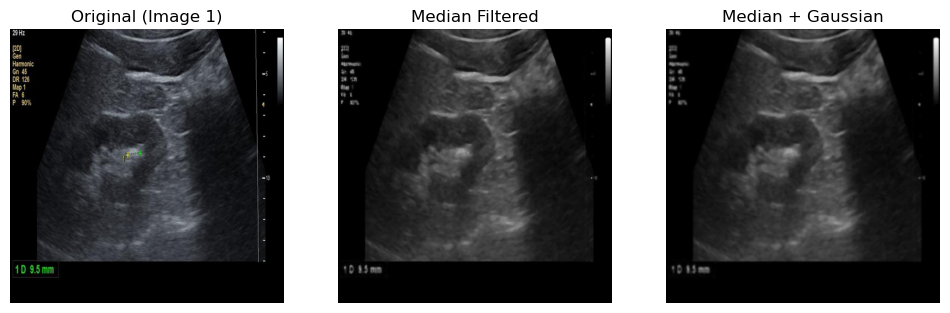

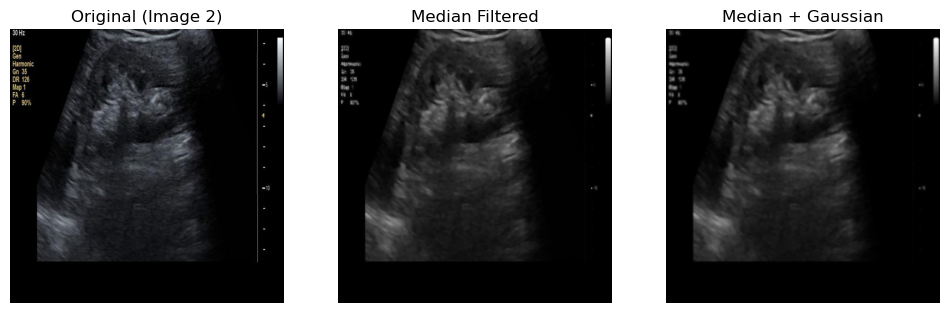

In [22]:
# show side by side(image 1 and image 2)
import matplotlib.pyplot as plt
from matplotlib.image import imread

for img_num in [1, 2]: 
    original = imread(f"dataset_images/img_{img_num}.jpg")
    median = imread(f"median_filtered_images/median_img_{img_num}.jpg")
    gaussian = imread(f"median_gaussian_filtered_images/median_gaussian_img_{img_num}.jpg")

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(original, cmap='gray')
    plt.title(f"Original (Image {img_num})")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(median, cmap='gray')
    plt.title("Median Filtered")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(gaussian, cmap='gray')
    plt.title("Median + Gaussian")
    plt.axis("off")

    plt.show()